# 🖨️ Darkroom Lab: The Master Printing Method

### Welcome to the Darkroom!
Today, we are taking a negative and turning it into a final, beautiful print. 

A lot of beginners think printing is just trial and error—guessing times until the picture looks okay. But fine-art printing is a structured craft. We do not want to rely blindly on automatic machines or expensive light meters. We want to train our eyes and our hands.

Here is our golden rule for making a perfect print:
**Expose for the highlights, and control the shadows with contrast.**

Let's break this down step-by-step using a method taught by master photographers.

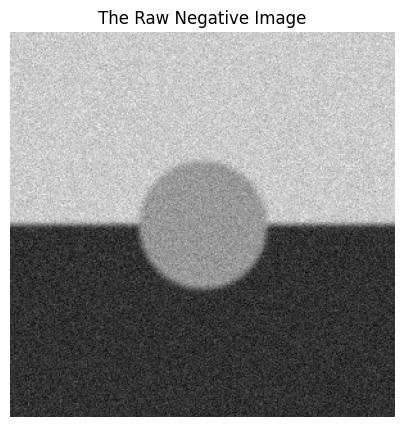

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Let's create a simulated "Negative" of a scene.
# We will simulate a bright wall (top), a dark foreground (bottom), and a subject (center).
def create_raw_negative():
    img = np.zeros((300, 300))
    img[0:150, :] = 0.8  # Bright wall
    img[150:300, :] = 0.2 # Dark foreground
    
    # Subject in the center
    y, x = np.ogrid[0:300, 0:300]
    subject_mask = (x - 150)**2 + (y - 150)**2 <= 50**2
    img[subject_mask] = 0.6
    
    # Add some natural blur and noise
    img = gaussian_filter(img, sigma=2)
    noise = np.random.normal(0, 0.05, img.shape)
    return np.clip(img + noise, 0, 1)

raw_negative = create_raw_negative()

plt.figure(figsize=(5, 5))
plt.imshow(raw_negative, cmap='gray')
plt.title("The Raw Negative Image")
plt.axis('off')
plt.show()

### Step 1: Expose for the Highlights (The Test Strip)
We never print a full sheet of paper first. That wastes money and time! 

Instead, we cut a small strip of paper and place it over the most important bright part of our image (the highlights). We cover the strip with a piece of cardboard, slowly moving the cardboard to give different sections of the strip more and more time under the enlarger light.

When we develop this strip, we look for **one thing only**: Which slice of time makes the highlights look perfect? We ignore the dark shadows completely for now.

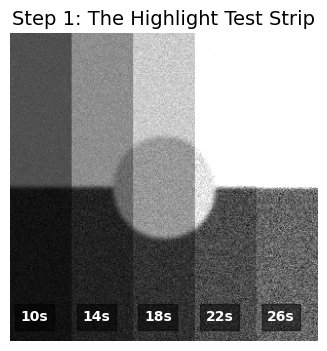

In [2]:
def simulate_test_strip(image):
    """Simulates a photographic test strip with increasing exposure times."""
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # We will simulate 5 different exposure times across the image
    test_strip = np.copy(image)
    
    # Slice the image into 5 columns
    step_width = 300 // 5
    exposures = [0.4, 0.7, 1.0, 1.5, 2.0] # Simulating time multipliers
    
    for i in range(5):
        start = i * step_width
        end = (i + 1) * step_width
        # Apply the exposure multiplier to each slice
        test_strip[:, start:end] = np.clip(test_strip[:, start:end] * exposures[i], 0, 1)
        
        # Add text to show the "seconds" for each strip
        ax.text(start + 10, 280, f"{10 + (i*4)}s", color='white', fontweight='bold', 
                bbox=dict(facecolor='black', alpha=0.5))

    ax.imshow(test_strip, cmap='gray')
    ax.set_title("Step 1: The Highlight Test Strip", fontsize=14)
    ax.axis('off')
    plt.show()

simulate_test_strip(raw_negative)

### Step 2: Control the Shadows with Contrast
Let's say we look at our test strip and decide that 18 seconds gives us the perfect, delicate highlight on our subject. We lock our timer at 18 seconds. 

Now, we print a **full sheet of paper**. 

When we look at this full sheet, the highlights are perfect, but what if the shadows look weak and gray? To fix this, we do not change the time. Instead, we change the **Contrast Grade** of the paper using filters. 
* A higher grade (like Grade 3) makes the darks darker and the brights brighter.
* A lower grade (like Grade 1) makes everything softer and more gray.

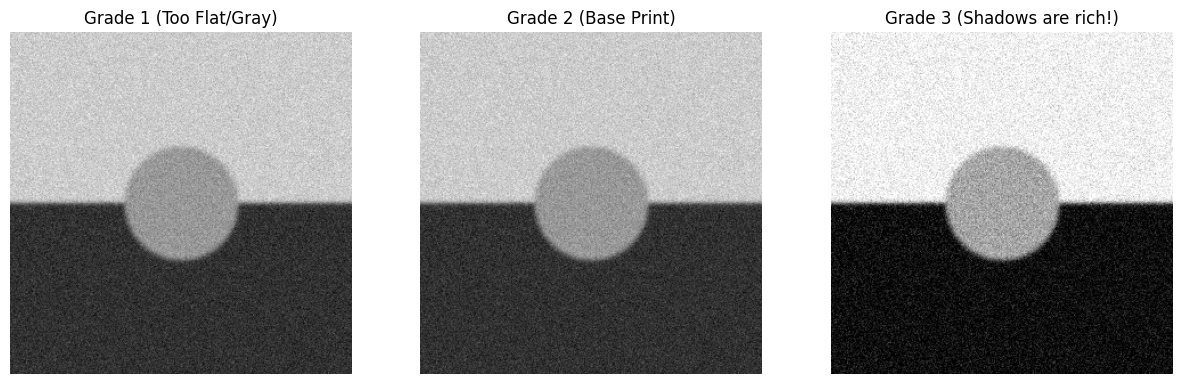

In [3]:
def simulate_contrast_grades(image):
    """Simulates applying different darkroom contrast filters to a full print."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Our locked-in base exposure
    base_exposure = np.clip(image * 1.0, 0, 1)
    
    # 1. Soft Contrast (Grade 1) - Low contrast curve
    grade_1 = np.clip((base_exposure - 0.5) * 0.7 + 0.5, 0, 1)
    axes[0].imshow(grade_1, cmap='gray')
    axes[0].set_title("Grade 1 (Too Flat/Gray)")
    axes[0].axis('off')
    
    # 2. Normal Contrast (Grade 2) - Standard
    grade_2 = base_exposure
    axes[1].imshow(grade_2, cmap='gray')
    axes[1].set_title("Grade 2 (Base Print)")
    axes[1].axis('off')
    
    # 3. High Contrast (Grade 3) - High contrast curve
    grade_3 = np.clip((base_exposure - 0.5) * 1.5 + 0.5, 0, 1)
    axes[2].imshow(grade_3, cmap='gray')
    axes[2].set_title("Grade 3 (Shadows are rich!)")
    axes[2].axis('off')
    
    plt.show()

simulate_contrast_grades(raw_negative)

### Step 3: Direct the Viewer's Eye (Dodging & Burning)
Now we have a great print! But human eyes are naturally drawn to the brightest parts of an image. If there is a bright, distracting wall in the background, the viewer will look at the wall instead of your subject.

We can fix this with two manual techniques:
1. **Burning:** Adding *extra* light to a specific area to make it darker and less distracting.
2. **Dodging:** Blocking the light from hitting a specific area to keep it brighter and draw attention to it.

We draw a "Printing Map" to plan exactly where our hands will dodge and burn during the exposure.

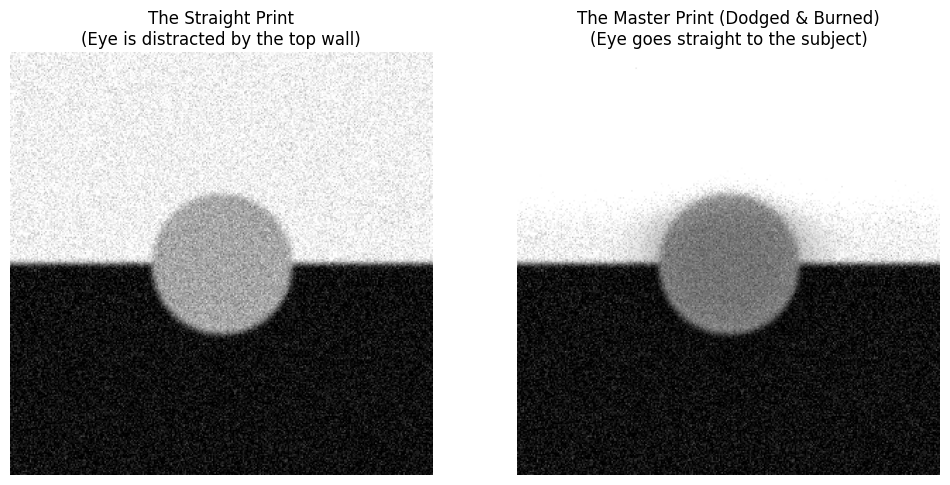

In [4]:
def simulate_dodging_and_burning(image):
    """Simulates local exposure adjustments (burning the background, dodging the subject)."""
    
    # Start with our best global print (Grade 3 from our previous step)
    base_print = np.clip((image - 0.5) * 1.5 + 0.5, 0, 1)
    
    # Create an empty mask for our adjustments
    adjustment_mask = np.ones((300, 300))
    
    # BURN: Darken the top wall so it isn't distracting
    # We simulate giving it 1.5x more light
    adjustment_mask[0:100, :] = 1.5 
    
    # DODGE: Keep the subject bright so the eye goes there
    # We simulate giving the center 0.7x less light
    y, x = np.ogrid[0:300, 0:300]
    subject_mask = (x - 150)**2 + (y - 150)**2 <= 60**2
    adjustment_mask[subject_mask] = 0.7
    
    # Smooth the mask so there are no hard edges (simulating moving your hands)
    adjustment_mask = gaussian_filter(adjustment_mask, sigma=15)
    
    # Apply the mask to the base print
    final_print = np.clip(base_print * adjustment_mask, 0, 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(base_print, cmap='gray')
    axes[0].set_title("The Straight Print\n(Eye is distracted by the top wall)")
    axes[0].axis('off')
    
    axes[1].imshow(final_print, cmap='gray')
    axes[1].set_title("The Master Print (Dodged & Burned)\n(Eye goes straight to the subject)")
    axes[1].axis('off')
    
    plt.show()

simulate_dodging_and_burning(raw_negative)

### Summary
By following a structured sequence, you remove the frustration from the darkroom. 
1. **Test Strip:** Find the perfect time for the highlights.
2. **Full Sheet:** Check the global contrast and adjust the paper grade.
3. **Map it out:** Use your hands to dodge and burn, guiding the viewer's eye exactly where you want it to go. 

Fine-art printing is a skill patiently acquired by training. Get your hands dirty, take notes on your printing maps, and watch your images come to life!